TUGAS PERTEMUAN 06 - PEMBELAJARAN MESIN DAN KECERDASAN BUATAN

Tugas 6A — "Kenali Tamumu": Segmentasi Booking Hotel Nyata

In [12]:
import pandas as pd

# Kode ini langsung mengambil file-nya dari internet secara otomatis!
# Anda TIDAK PERLU download atau pindah-pindah file lagi.
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
df = pd.read_csv(url)

# Simpan otomatis ke folder Anda sekarang
df.to_csv("hotel_bookings.csv", index=False)

print("BERHASIL! File sudah siap digunakan.")

BERHASIL! File sudah siap digunakan.


--- EVALUASI JUMLAH CLUSTER (k) ---
   k  Inertia (Z)  Silhouette (Z)  Silhouette (Mentah)
0  2       192437           0.190                0.538
1  3       167046           0.204                0.517
2  4       145317           0.236                0.506
3  5       129123           0.239                0.500
4  6       116396           0.225                0.468
5  7       104410           0.237                0.460
6  8        96949           0.250                0.438

--- PROFIL SEGMEN DALAM SATUAN ASLI ---
         lead_time  total_nights  adults  children    adr  \
cluster                                                     
0             36.4           3.1     2.0       0.0   97.7   
1            195.8           7.4     2.0       0.0   91.2   
2             27.0           2.4     1.0       0.0   54.2   
3             75.1           4.4     2.1       1.4  164.2   

         total_of_special_requests  previous_bookings_not_canceled  \
cluster                                       

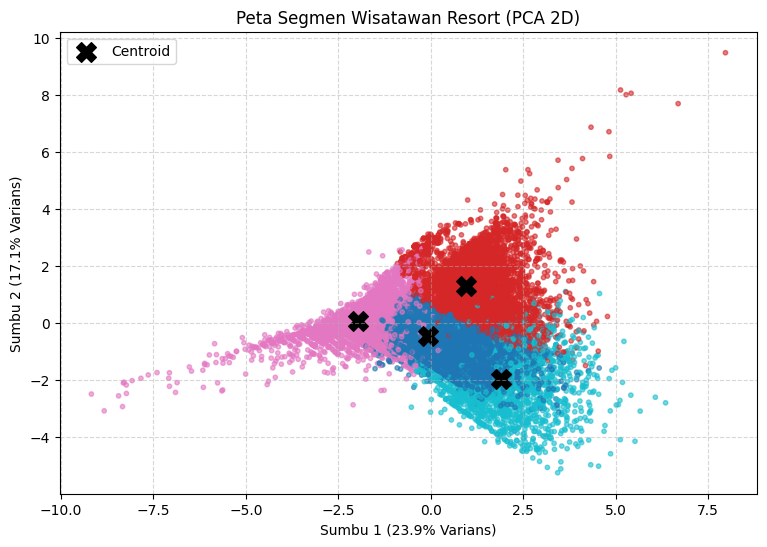


Bobot Fitur pada Sumbu PCA (Loadings):
                                 PC1   PC2
lead_time                       0.36  0.55
total_nights                    0.40  0.48
adults                          0.49 -0.13
children                        0.28 -0.41
adr                             0.47 -0.42
total_of_special_requests       0.29 -0.25
previous_bookings_not_canceled -0.27 -0.09
booking_changes                 0.15  0.18


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. PERSIAPAN DATASET
# ---------------------------------------------------------
# Memuat dataset Hotel Booking Demand dari Kaggle (hotel_bookings.csv)
df = pd.read_csv("hotel_bookings.csv")

# Filter: Ambil Resort Hotel & reservasi yang TIDAK dibatalkan (is_canceled == 0)
resort_df = df[(df["hotel"] == "Resort Hotel") & (df["is_canceled"] == 0)].copy()

# Buat fitur total malam
resort_df["total_nights"] = resort_df["stays_in_weekend_nights"] + resort_df["stays_in_week_nights"]

# Pilih fitur numerik yang ditentukan
fitur = [
    "lead_time",
    "total_nights",
    "adults",
    "children",
    "adr",
    "total_of_special_requests",
    "previous_bookings_not_canceled",
    "booking_changes"
]

# Pembersihan Data: Isi nilai kosong & buang ADR invalid (<= 0 atau outlier ekstrim > 1000)
data_clean = resort_df[fitur].copy()
data_clean["children"] = data_clean["children"].fillna(0)
data_clean = data_clean[(data_clean["adr"] > 0) & (data_clean["adr"] <= 1000)].reset_index(drop=True)

# Standardization (z-score)
scaler = StandardScaler()
Z = scaler.fit_transform(data_clean)

# ---------------------------------------------------------
# 2. EVALUASI JUMLAH CLUSTER (k = 2...8)
# ---------------------------------------------------------
hasil_k = []
for k in range(2, 9):
    # Model dengan StandardScaler
    km_z = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
    sil_z = silhouette_score(Z, km_z.labels_)

    # Model tanpa StandardScaler (Data Mentah)
    km_m = KMeans(n_clusters=k, n_init=10, random_state=0).fit(data_clean)
    sil_m = silhouette_score(data_clean, km_m.labels_)

    hasil_k.append((k, round(km_z.inertia_), round(sil_z, 3), round(sil_m, 3)))

df_evaluasi = pd.DataFrame(hasil_k, columns=["k", "Inertia (Z)", "Silhouette (Z)", "Silhouette (Mentah)"])
print("--- EVALUASI JUMLAH CLUSTER (k) ---")
print(df_evaluasi)

# ---------------------------------------------------------
# 3. FIT MODEL K-MEANS DENGAN k PILIHAN (k = 4)
# ---------------------------------------------------------
k_pilihan = 4
km_final = KMeans(n_clusters=k_pilihan, n_init=10, random_state=0).fit(Z)
data_clean["cluster"] = km_final.labels_

# Profil Kerumunan dalam SATUAN ASLI
profil_segmen = data_clean.groupby("cluster").mean().round(1)
profil_segmen["jumlah_tamu"] = data_clean["cluster"].value_counts().sort_index()

print("\n--- PROFIL SEGMEN DALAM SATUAN ASLI ---")
print(profil_segmen)

# ---------------------------------------------------------
# 4. PETA CLUSTER 2D MENGGUNAKAN PCA
# ---------------------------------------------------------
pca = PCA(n_components=2).fit(Z)
P = pca.transform(Z)

plt.figure(figsize=(9, 6))
plt.scatter(P[:, 0], P[:, 1], c=data_clean["cluster"], s=10, cmap="tab10", alpha=0.6)

pusat_pca = pca.transform(km_final.cluster_centers_)
plt.scatter(pusat_pca[:, 0], pusat_pca[:, 1], marker="X", s=200, c="black", label="Centroid")

plt.title("Peta Segmen Wisatawan Resort (PCA 2D)")
plt.xlabel(f"Sumbu 1 ({round(pca.explained_variance_ratio_[0]*100, 1)}% Varians)")
plt.ylabel(f"Sumbu 2 ({round(pca.explained_variance_ratio_[1]*100, 1)}% Varians)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("\nBobot Fitur pada Sumbu PCA (Loadings):")
df_loadings = pd.DataFrame(pca.components_.T, index=fitur, columns=["PC1", "PC2"]).round(2)
print(df_loadings)

Tugas 6B — "Tiga Angka untuk GM": PCA Survei + Segmen Kepuasan

--- SUMMARY PCA SURVEI ---
  Komponen  Porsi Varians  Kumulatif Varians
0      PC1          0.372              0.372
1      PC2          0.229              0.601
2      PC3          0.118              0.719
3      PC4          0.049              0.768
4      PC5          0.045              0.813
5      PC6          0.042              0.855
6      PC7          0.039              0.894
7      PC8          0.038              0.932
8      PC9          0.036              0.968
9     PC10          0.032              1.000

--- TABEL BOBOT PERTANYAAN (LOADINGS) ---
                   PC1 (Umum)  PC2 (Fisik vs Staf)  PC3 (Nilai Uang)
kebersihan_kamar         0.36                -0.25             -0.29
kenyamanan_kasur         0.32                -0.36             -0.16
kebersihan_kolam         0.35                -0.28             -0.30
kecepatan_wifi           0.32                -0.34             -0.00
keramahan_staf           0.29                 0.42             -0.16
kecepatan_checkin    

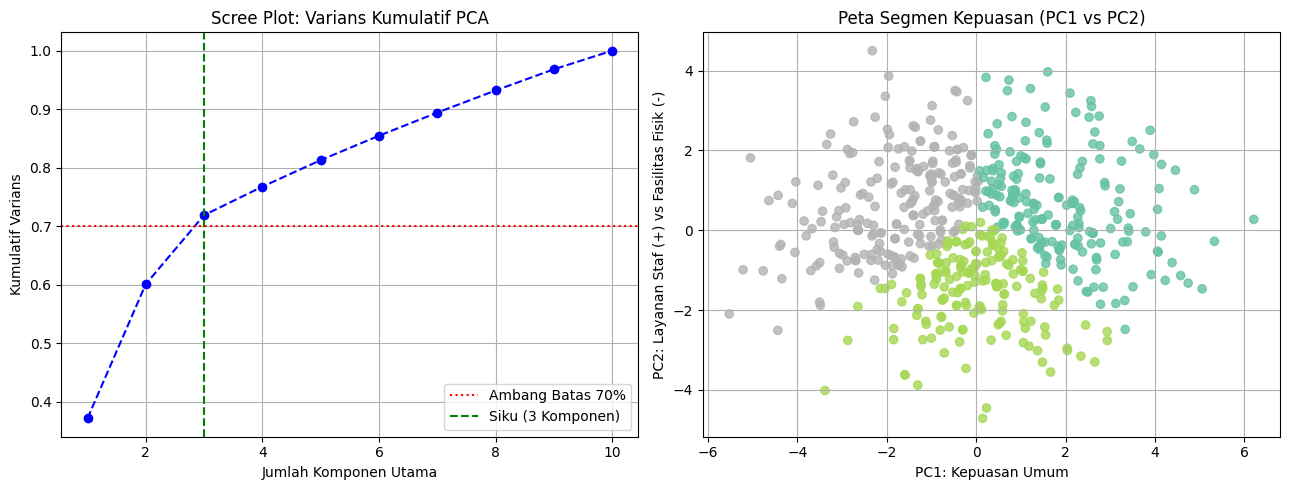

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 1. SIMULASI DATA SURVEI KEPUASAN (600 Tamu, 10 Pertanyaan)
# ---------------------------------------------------------
rng = np.random.default_rng(66)
m = 600

f_fisik, f_layanan, f_nilai = rng.normal(0, 1, (3, m))

bobot = {
    "kebersihan_kamar": (0.9, 0.1, 0.0),
    "kenyamanan_kasur": (0.85, 0.0, 0.1),
    "kebersihan_kolam": (0.8, 0.1, 0.0),
    "kecepatan_wifi": (0.6, 0.0, 0.2),
    "keramahan_staf": (0.1, 0.9, 0.0),
    "kecepatan_checkin": (0.0, 0.85, 0.1),
    "kualitas_sarapan": (0.3, 0.6, 0.1),
    "info_tur_jelas": (0.0, 0.8, 0.1),
    "harga_sepadan": (0.2, 0.1, 0.9),
    "variasi_menu": (0.3, 0.3, 0.6)
}

survei = pd.DataFrame({
    q: np.clip(np.round(3.6 + 0.7 * (a*f_fisik + b*f_layanan + c*f_nilai) + rng.normal(0, 0.35, m)), 1, 5)
    for q, (a, b, c) in bobot.items()
})

# ---------------------------------------------------------
# 2. EKSTRAKSI INDEKS MENGGUNAKAN PCA
# ---------------------------------------------------------
Zs = StandardScaler().fit_transform(survei)
pca_full = PCA().fit(Zs)

porsi_varians = pca_full.explained_variance_ratio_
kumulatif_varians = porsi_varians.cumsum()

df_pca_summary = pd.DataFrame({
    "Komponen": [f"PC{i+1}" for i in range(len(porsi_varians))],
    "Porsi Varians": porsi_varians.round(3),
    "Kumulatif Varians": kumulatif_varians.round(3)
})
print("--- SUMMARY PCA SURVEI ---")
print(df_pca_summary)

# Pilih 3 Komponen Utama (~72% kumulatif varians)
pca_3 = PCA(n_components=3).fit(Zs)
skor_pca = pca_3.transform(Zs)

df_bobot = pd.DataFrame(pca_3.components_.T, index=survei.columns, columns=["PC1 (Umum)", "PC2 (Fisik vs Staf)", "PC3 (Nilai Uang)"]).round(2)
print("\n--- TABEL BOBOT PERTANYAAN (LOADINGS) ---")
print(df_bobot)

# ---------------------------------------------------------
# 3. K-MEANS PADA SKOR PCA (SEGMEN KEPUASAN)
# ---------------------------------------------------------
km_survei = KMeans(n_clusters=3, n_init=10, random_state=0).fit(skor_pca)
df_skor = pd.DataFrame(skor_pca, columns=["PC1", "PC2", "PC3"])
df_skor["segmen_kepuasan"] = km_survei.labels_

print("\n--- RATA-RATA SKOR INDEKS PER SEGMEN KEPUASAN ---")
print(df_skor.groupby("segmen_kepuasan").mean().round(2))

# ---------------------------------------------------------
# 4. DASHBOARD 1 HALAMAN UNTUK GENERAL MANAGER (GM)
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Scree Plot Varians Kumulatif
axs[0].plot(range(1, 11), kumulatif_varians, marker="o", linestyle="--", color="b")
axs[0].axhline(y=0.70, color="r", linestyle=":", label="Ambang Batas 70%")
axs[0].axvline(x=3, color="g", linestyle="--", label="Siku (3 Komponen)")
axs[0].set_title("Scree Plot: Varians Kumulatif PCA")
axs[0].set_xlabel("Jumlah Komponen Utama")
axs[0].set_ylabel("Kumulatif Varians")
axs[0].legend()
axs[0].grid(True)

# Plot 2: Distribusi Segmen Kepuasan pada PC1 vs PC2
scatter = axs[1].scatter(skor_pca[:, 0], skor_pca[:, 1], c=km_survei.labels_, cmap="Set2", alpha=0.8)
axs[1].set_title("Peta Segmen Kepuasan (PC1 vs PC2)")
axs[1].set_xlabel("PC1: Kepuasan Umum")
axs[1].set_ylabel("PC2: Layanan Staf (+) vs Fasilitas Fisik (-)")
axs[1].grid(True)

plt.tight_layout()
plt.show()